In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('slot_attention')

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from multi_object_datasets_torch import ClevrWithMasks
from slot_attention.model import SlotAttentionModel
from torch.utils.data import DataLoader
from torchvision import transforms
from slot_attention.utils import compute_ari, visualize_masks, rescale
from PIL import Image

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = ClevrWithMasks('datasets', split='test')

In [4]:
import torch
from torch.utils.data import Dataset

class FilteredDataset(Dataset):
    def __init__(self, base_dataset, max_nonzeros=5):
        self.base = base_dataset
        self.max_nonzeros = max_nonzeros

        self.to_pil = transforms.ToPILImage()
        self.to_tensor = transforms.ToTensor()

        self.filtered_idxs = []
        for i in range(len(self.base)):
            vis = self.base[i]['visibility']
            if (vis != 0).sum().item() == max_nonzeros:
                self.filtered_idxs.append(i)
                # break

    def __len__(self):
        return len(self.filtered_idxs)

    def __getitem__(self, idx):
        orig = self.base[self.filtered_idxs[idx]]
        
        img = orig['image']
        img = self.to_tensor(self.to_pil(img).convert("RGB"))

        nz_idx = (orig['visibility'] != 0).nonzero(as_tuple=True)[0]
        mask = orig['mask'][nz_idx]

        out = {
            'image': img,
            'mask': mask
        }
        return out

In [5]:
fdata = FilteredDataset(data)
batch_size = 32
dataloader = DataLoader(fdata, batch_size=batch_size, shuffle=False)

clevr_transforms = transforms.Compose([
    transforms.Lambda(rescale),  # rescale between -1 and 1
    transforms.Resize((128, 128)),
])

In [20]:
from torchmetrics.image import StructuralSimilarityIndexMeasure
ssim = StructuralSimilarityIndexMeasure(data_range=(-1.0, 1.0))


def model_metrics(model, dataloader, device):
    model.eval()
    ari_scores = []
    ssim_scores = []

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            # Get images and masks from dataset
            images = clevr_transforms(batch['image'].to(device).to(torch.float32))
            resize = transforms.Resize((128, 128))
            true_masks = resize(batch['mask'].squeeze(2).to(device)).unsqueeze(2)
            
            # Forward pass through model
            recon_combined, recons, pred_masks, slots = model(images)

            # remove background from masks
            true_masks = true_masks[:, 1:, :, :, :]
            # detect bg mask in predictions and remove it
            areas = pred_masks.sum(dim=(0, 2, 3, 4))
            bg_idx = areas.argmax()
            mask = torch.arange(pred_masks.size(1), device=device) != bg_idx
            pred_masks = pred_masks[:, mask, :, :, :]
            
            # Compute ARI
            batch_ari = compute_ari(true_masks, pred_masks)
            ari_scores.append(batch_ari.cpu().numpy())

            batch_ssim = ssim(recon_combined.cpu(), images.cpu())
            ssim_scores.append(batch_ssim.cpu().numpy())
            
            if i >= 4:
                break
    return np.mean(np.concatenate(ari_scores)), np.mean(ssim_scores)

In [22]:
from collections import OrderedDict

resolution = (128, 128)
num_slots = 5 
num_iterations = 3

exp = [
    ('base_sa', 'base'),
    ('focused_sa', 'focused'),
    ('focused_with_dwc_sa_var1', 'focuseddwc'),
    ('focused_with_dwc_sa_var2', 'focuseddwc'),
    ('favor', 'favor'),
    ('favor_no_norm', 'favor_no_norm'),
]
res = {}

for cpt_path, sa_type in exp:
    w = OrderedDict()
    sd = torch.load(f'slot-attention-clevr6/{cpt_path}.ckpt')['state_dict']
    for k, v in sd.items():
        w[k[6:]] = v

    model = SlotAttentionModel(
        resolution=resolution,
        num_slots=num_slots,
        num_iterations=num_iterations,
        vers=sa_type
    ).to(device)
    model.load_state_dict(w)

    avg_ari, avg_ssim = model_metrics(model, dataloader, device)
    print(f"{cpt_path}: ARI={avg_ari:.5f}, SSIM={avg_ssim:.5f}")

    res[cpt_path] = {'ari': avg_ari, 'ssim': avg_ssim}

/tmp/ipykernel_15066/2174494968.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(f'slot-attention-clevr6/{cpt_path}.ckpt')['state_dict']


base_sa: ARI=0.83913, SSIM=0.87125
focused_sa: ARI=0.69131, SSIM=0.82837
focused_with_dwc_sa_var1: ARI=0.75907, SSIM=0.83929
focused_with_dwc_sa_var2: ARI=0.48944, SSIM=0.56707
favor: ARI=0.12250, SSIM=0.56597
favor_no_norm: ARI=0.14394, SSIM=0.50061


In [27]:
ari = list(zip(*((k, v['ari']) for k, v in res.items())))
ssim = list(zip(*((k, v['ssim']) for k, v in res.items())))

In [28]:
ari

[('base_sa',
  'focused_sa',
  'focused_with_dwc_sa_var1',
  'focused_with_dwc_sa_var2',
  'favor',
  'favor_no_norm'),
 (np.float32(0.8391283),
  np.float32(0.6913136),
  np.float32(0.75907195),
  np.float32(0.48943624),
  np.float32(0.12249877),
  np.float32(0.1439441))]

/tmp/ipykernel_15066/1886731830.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ari[0], y=ari[1], ax=ax1, palette=pp)
/tmp/ipykernel_15066/1886731830.py:28: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.barplot(x=ari[0], y=ari[1], ax=ax1, palette=pp)
/tmp/ipykernel_15066/1886731830.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ssim[0], y=ssim[1], ax=ax2, palette=pp)
/tmp/ipykernel_15066/1886731830.py:34: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.barplot(x=ssim[0], y=ssim[1], ax=ax2, palette=pp)


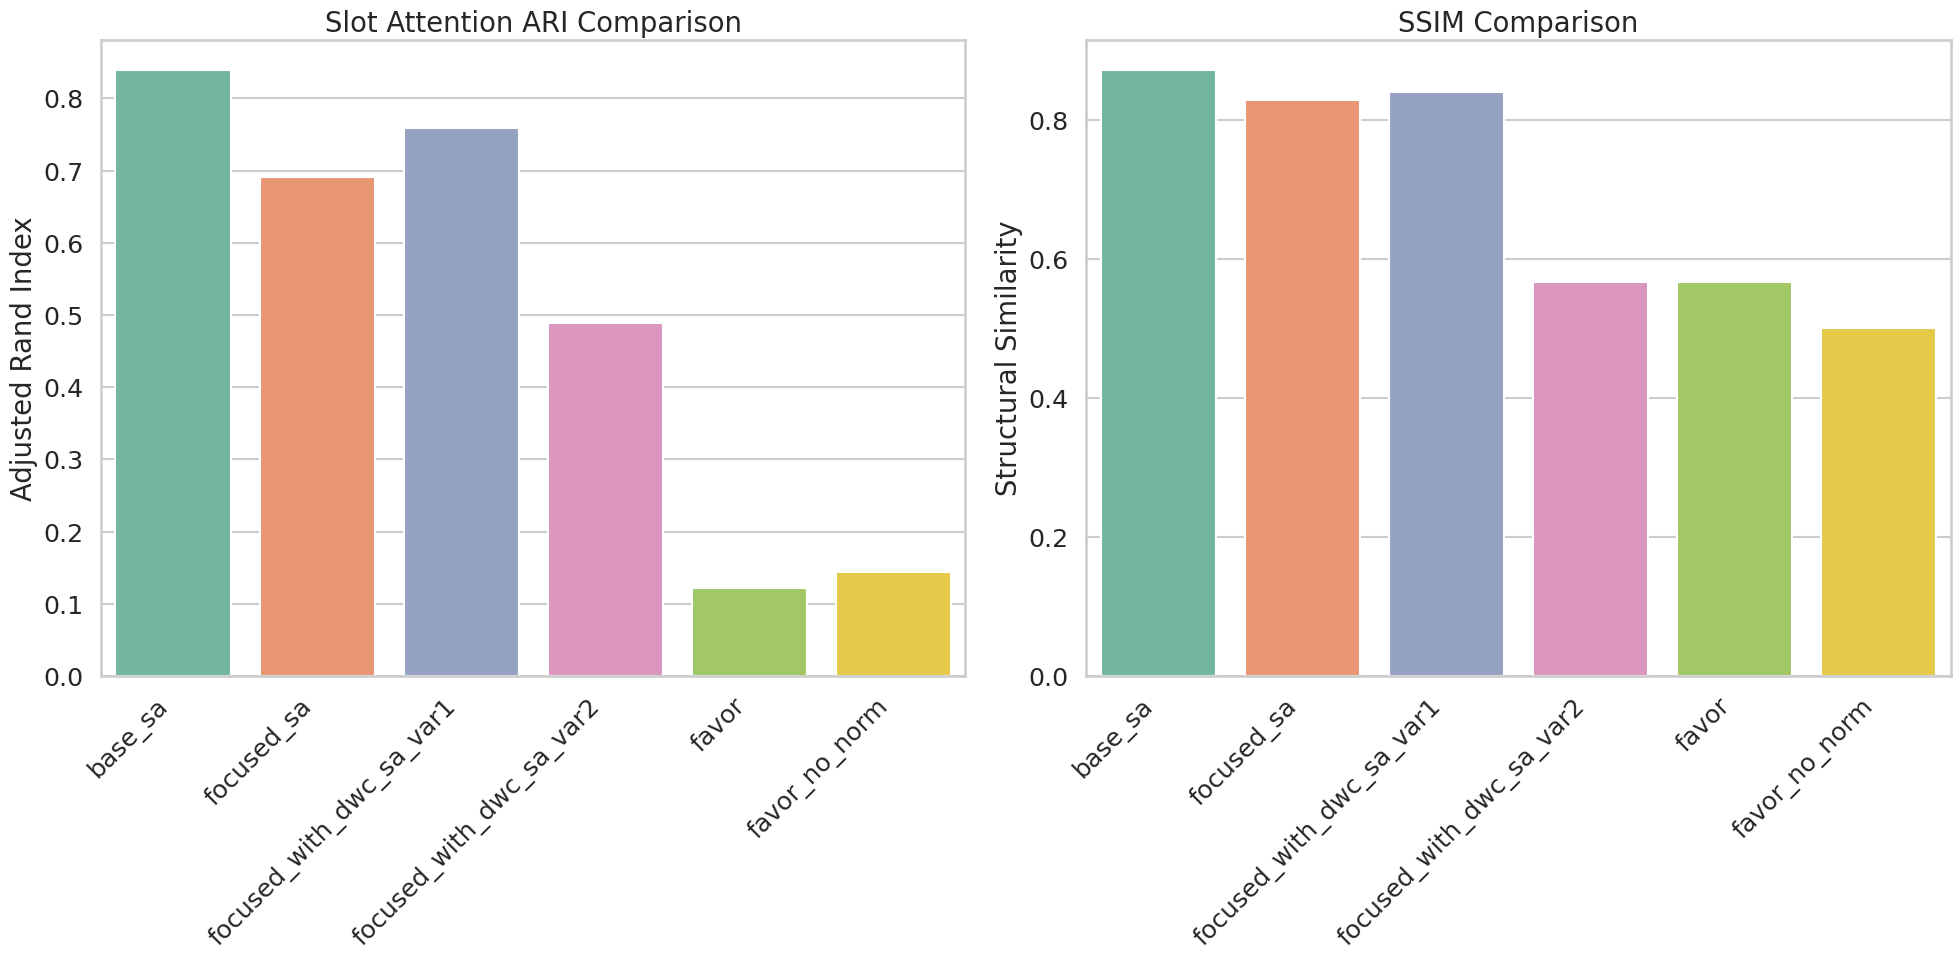

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(
    context="talk",
    style="whitegrid",
    palette="pastel",
    font_scale=1.1
)

pp = sns.color_palette([
  "#66C2A5",  # a muted teal
  "#FC8D62",  # a warm orange
  "#8DA0CB",  # a soft blue
  "#E78AC3",  # a gentle pink
  "#A6D854",  # a fresh lime
  "#FFD92F",  # a mellow yellow
  "#E5C494",  # a sandy beige
  "#B3B3B3",  # a neutral gray
])
# Create a figure with 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# ax1.tick_params(axis='x', rotation=45)
# ax2.tick_params(axis='x', rotation=45)
# Left barplot
sns.barplot(x=ari[0], y=ari[1], ax=ax1, palette=pp)
ax1.set_title('Slot Attention ARI Comparison')
# ax1.set_xlabel('Attention variant')
ax1.set_ylabel('Adjusted Rand Index')

# Right barplot
sns.barplot(x=ssim[0], y=ssim[1], ax=ax2, palette=pp)
ax2.set_title('SSIM Comparison')
# ax2.set_xlabel('Attention variant')
ax2.set_ylabel('Structural Similarity')

# sns.despine(trim=True, offset=5)

for ax in [ax1, ax2]:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

plt.tight_layout()
plt.show()
